In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import cv2
from tensorflow import keras
import glob,os
from sklearn.preprocessing import  LabelBinarizer
from sklearn.model_selection import train_test_split


In [44]:
IMAGE_SIZE = 256
BATCH_SIZE= 34
CHANNELS= 2
EPOCHS=50

In [3]:
dataset= tf.keras.preprocessing.image_dataset_from_directory(
    "colored_images",
    shuffle= True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size= BATCH_SIZE
)


Found 3662 files belonging to 5 classes.


In [4]:
class_names= dataset.class_names
class_names

['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']

In [5]:
for image_batch, label_batch in dataset.take(1):
   print (image_batch. shape)
   print(label_batch.numpy())


(34, 256, 256, 3)
[1 1 2 2 1 1 2 1 1 2 2 1 0 1 2 2 1 2 1 2 2 2 2 2 0 2 1 2 2 1 2 2 1 3]


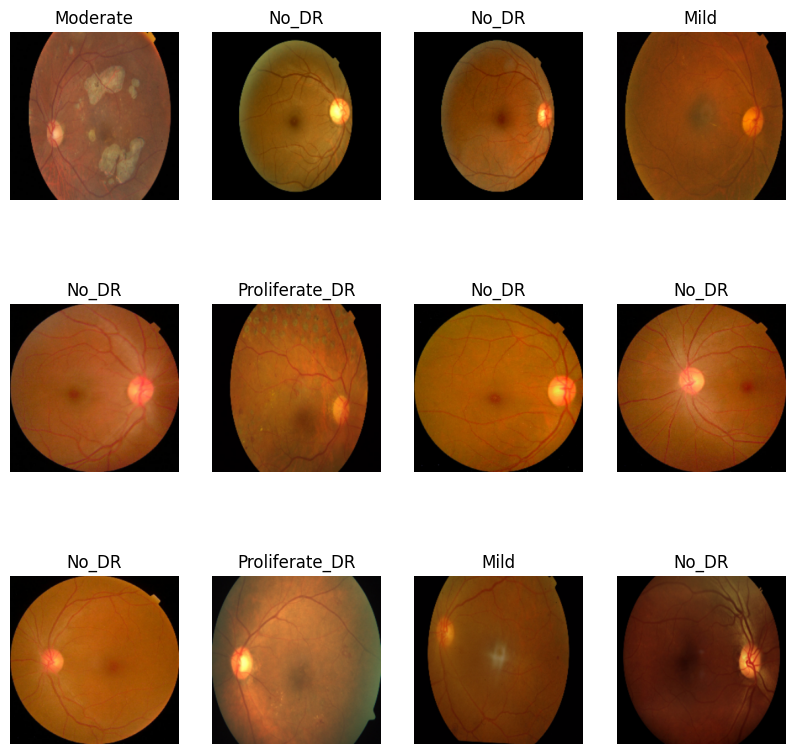

In [6]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [7]:
len(dataset)

108

In [8]:
train_size = 0.8
len(dataset)*train_size

86.4

In [9]:
train_ds = dataset.take(54)
len(train_ds)

54

In [10]:
test_ds = dataset.skip(54)
len(test_ds)

54

In [11]:
val_size=0.1
len(dataset)*val_size

10.8

In [12]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [13]:
test_ds = test_ds.skip(6)
len(test_ds)

48

In [14]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
         ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds


In [15]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [16]:
len(train_ds)

86

In [17]:
train_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds= val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds= test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [18]:
resize_and_rescale = tf.keras.Sequential([
layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
layers.experimental . preprocessing .Rescaling(1.0/255)
])


In [19]:
data_augmentation = tf.keras.Sequential([
layers. experimental . preprocessing. RandomFlip("horizontal_and_vertical"),
layers.experimental . preprocessing .RandomRotation(0.2),
])


In [20]:
from tensorflow.keras.optimizers.legacy import Adam

In [21]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


In [22]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [23]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (34, 256, 256, 3)         0         
                                                                 
 conv2d (Conv2D)             (34, 254, 254, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (34, 127, 127, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (34, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (34, 62, 62, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (34, 60, 60, 64)         

In [24]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [25]:
mild_path=glob.glob(r'gaussian_filtered_images/Mild/*.png')
moderate_path=glob.glob(r'gaussian_filtered_images/Moderate/*.png')
proliferate_dr_path=glob.glob(r'gaussian_filtered_images/Proliferate_DR/*.png')
severe_path=glob.glob(r'gaussian_filtered_images/Severe/*.png')

In [26]:
mild_dir=[]
moderate_dir=[]
no_dr_dir=[]
proliferate_dr_dir=[]
severe_dir=[]
for i in mild_path:
    img=cv2.imread(i,1)
    img=cv2.resize(img,(128,128))
    img=img/255
    mild_dir.append(img)
for i in moderate_path:
    img=cv2.imread(i,1)
    img=cv2.resize(img,(128,128))
    img=img/255
    moderate_dir.append(img)
for i in proliferate_dr_path:
    img=cv2.imread(i,1)
    img=cv2.resize(img,(128,128))
    img=img/255
    proliferate_dr_dir.append(img)
for i in severe_path:
    img=cv2.imread(i,1)
    img=cv2.resize(img,(128,128))
    img=img/255
    severe_dir.append(img)

In [27]:
def data_import(mild_dir,moderate_dir,proliferate_dr_dir,severe_dir):
    df_data_mild = pd.DataFrame({'image':mild_dir, 'label': 'mild'})
    df_data_moderate = pd.DataFrame({'image':moderate_dir, 'label': 'moderate'})
    #df_data_no = pd.DataFrame({'image':no_dr_dir, 'label': 'no_DR'})
    df_data_proliferate = pd.DataFrame({'image':proliferate_dr_dir, 'label': 'proliferate_DR'})
    df_data_severe = pd.DataFrame({'image':severe_dir, 'label': 'severe'})

    
    final_data = [df_data_mild, df_data_moderate,df_data_proliferate,df_data_severe]
    final_data = pd.concat(final_data)
    
    all_data = final_data['image']
    labels = final_data['label']
    all_data=np.stack(all_data,axis=0)
    labels = LabelBinarizer().fit_transform(labels)
    return all_data,labels

In [28]:
dataset,labels   = data_import(mild_dir,moderate_dir,proliferate_dr_dir,severe_dir)

In [29]:
x=dataset
y = np.where(labels==1)[1]

from tensorflow.keras.utils import to_categorical
y_onehot = to_categorical(y)

x_train,x_test,y_train,y_test = train_test_split(x,y_onehot,test_size=0.25,stratify=y_onehot)

In [30]:
from keras.models import Sequential
from keras.layers import GaussianNoise
from keras.layers import GlobalAveragePooling2D
from keras.layers import Dense
from keras.layers import BatchNormalization
from keras.layers import Dropout

base_model = tf.keras.applications.EfficientNetB3(weights='imagenet', input_shape=(128,128,3), include_top=False)

for layer in base_model.layers:
    layer.trainable=False
model = Sequential()
model.add(base_model)
model.add(GaussianNoise(0.25))
model.add(GlobalAveragePooling2D())
model.add(Dense(512,activation='relu'))
model.add(BatchNormalization())
model.add(GaussianNoise(0.25))
model.add(Dropout(0.25))
model.add(Dense(4, activation='softmax'))
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy','AUC','Precision','Recall'])

In [31]:
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
44/44 [==============================] - 48s 744ms/step - loss: 1.8077 - accuracy: 0.2945 - auc: 0.5470 - precision: 0.3119 - recall: 0.1918
Epoch 2/10
44/44 [==============================] - 31s 706ms/step - loss: 1.5863 - accuracy: 0.3822 - auc: 0.6293 - precision: 0.4195 - recall: 0.2809
Epoch 3/10
44/44 [==============================] - 31s 704ms/step - loss: 1.4681 - accuracy: 0.4418 - auc: 0.6629 - precision: 0.4886 - recall: 0.3240
Epoch 4/10
44/44 [==============================] - 33s 748ms/step - loss: 1.3906 - accuracy: 0.4483 - auc: 0.6761 - precision: 0.5022 - recall: 0.3211
Epoch 5/10
44/44 [==============================] - 38s 855ms/step - loss: 1.3603 - accuracy: 0.4583 - auc: 0.6816 - precision: 0.4983 - recall: 0.3111
Epoch 6/10
44/44 [==============================] - 34s 779ms/step - loss: 1.2978 - accuracy: 0.4842 - auc: 0.6988 - precision: 0.5249 - recall: 0.3261
Epoch 7/10
44/44 [==============================] - 33s 750ms/step - loss: 1.2863 - accu

In [32]:
model.evaluate(x_train,y_train)

44/44 [==============================] - 32s 678ms/step - loss: 1.3769 - accuracy: 0.1588 - auc: 0.5836 - precision: 0.0000e+00 - recall: 0.0000e+00


[1.3768962621688843, 0.15876436233520508, 0.5835522413253784, 0.0, 0.0]

In [33]:
model.evaluate(x_test,y_test)

15/15 [==============================] - 11s 745ms/step - loss: 1.3756 - accuracy: 0.1591 - auc: 0.5825 - precision: 0.0000e+00 - recall: 0.0000e+00


[1.3755877017974854, 0.15913978219032288, 0.5824827551841736, 0.0, 0.0]

In [101]:
x_train.shape

(2, 49152)

In [102]:
x_test.shape

(465, 128, 128, 3)

In [105]:
y_train.shape

(2, 4)

In [104]:
y_test.shape

(465, 4)

In [53]:
x_train = x_train.reshape(34,224*224)
x_test = x_test.reshape(34,224*224)

ValueError: cannot reshape array of size 98304 into shape (34,50176)

In [40]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 100) 
model.fit(x_train, y_train.ravel())
y_pred = model.predict(X_test)
 
print("ACCURACY OF THE MODEL: ", accuracy_score(y_test, y_pred))

ValueError: Found array with dim 4. RandomForestClassifier expected <= 2.